# ICT-15d — Cochaîne de Čech pondérée : obstruction intra-substrat

**Issue** : [#7744](https://github.com/jsboige/CoursIA/issues/7744) (jambe transverse #7395/#4588).
**Module outillant le notebook** : `ict.cech_obstruction` (PR #8828 MERGED `feat/ict-cech-obstruction-7744`).
**Requis ICT-15c** : ce notebook complète l'échelle ICT-15 (Integrated Complexity, strate 5) en passant
de la **comparaison entre substrats** (Phase Zéro, `ict.meta_proxy`, ICT-15c) à la **structure
relationnelle intra-substrat** : rangs, résidus de transport, holonomie cyclique.

## Diagnostic ferme (audit tour 369, cf issue #7744)

`ict.meta_proxy` ("Phase Zéro") détecte la **dispersion des signatures entre substrats** : il compare
les niveaux bruts (gap spectral, sensibilité moyenne/max) *d'un substrat à l'autre*. Le diagnostic est
que ce n'est pas une obstruction : comparer des niveaux bruts (même normalisés) mesure un écart
d'échelle, pas un *motif de désaccord structurel*.

Ce notebook applique la **cochaîne de Čech pondérée** (`ict.cech_obstruction`) pour répondre à la question
fine : *sur un seul substrat, est-ce que plusieurs proxys se "recollent" en une mesure globale unique ?*

## Objet mathématique : la cochaîne de Čech pondérée

On découpe la trajectoire d'un substrat en fenêtres contiguës. Chaque proxy devient une **section
locale** (sa valeur scalaire par fenêtre). Sur ces sections :

| Objet Čech | Ici | Signification |
|---|---|---|
| **Recouvrement double** (cobord, 1-cochaîne) | `transport_residual(s_i, s_j)` | résidu post-ajustement affine ; absorbé si purement affine |
| **Recouvrement triple** (cocycle, 2-cochaîne) | `holonomy(r_ij, r_jk, r_ki)` | somme cyclique des résidus ; non-nulle = désaccord cyclique |
| **Non-nullité de la classe** | `effective_dimensionality` (SVD) | 1D affine (trivial) vs ≥2D (obstruction) |

**Verdict falsifiable** : `NON_TRIVIAL` si la dimensionnalité effective ≥ 2 ET le cobord moyen dépasse un
plancher (désaccord réel). `TRIVIAL` sinon. `INCONCLUSIVE` si moins de 3 proxys.

## Acceptance (#7744)

**Positif** : sur ≥ 1 substrat ICT, la lecture-obstruction **change une décision expérimentale ou une
visualisation** (ex : reclasser un régime "dispersion" en régime "obstruction", ou disqualifier un proxy).

**Négatif honnête** : sur tous les substrats, les proxys se réduisent à un signal latent 1D — 
échec du candidat à constater une obstruction, la jambe transverse meurt proprement.

## Substrats

Mêmes substrats qu'ICT-15c : **Gray-Scott** (Turing), **Axelrod** (réplicateur), **Grokking** (compression
crossover), **May** (ICT-8, pâturage bistable). Déterministes (seeds fixés).


In [1]:
# Imports et setup
import sys
from pathlib import Path
import numpy as np

ICT_ROOT = Path('.').resolve()
if str(ICT_ROOT) not in sys.path:
    sys.path.insert(0, str(ICT_ROOT))

from ict import cech_obstruction as CO
from ict import spectral as SP
from ict import sensitivity as SE
from ict import meta_proxy as MP

print("ict.cech_obstruction charg\u00e9. Fonctions publiques :")
for fn in ['proxy_sections', 'normalize_sections', 'effective_dimensionality',
          'transport_residual', 'holonomy', 'cech_obstruction_class',
          'cech_obstruction_verdict', 'cech_obstruction_test']:
    print(f"  - {fn}")

# Helper : wrap un proxy callable pour proxy_sections (même signature que MP.ProxyFn).
def spec_gap_wrap(states, n_symbols):
    return float(SP.spectral_summary(states, n_symbols)['spectral_gap'])

def sens_mean_wrap(states, n_symbols):
    f = lambda x: x  # identité sur le vocabulaire ordinal (cf L932 desaturation)
    return float(SE.sensitivity_distribution(states, n_symbols, f)['mean'])

def sens_max_wrap(states, n_symbols):
    f = lambda x: x
    return float(SE.sensitivity_distribution(states, n_symbols, f)['max'])

PROXIES = {
    "spectral_gap": spec_gap_wrap,
    "sens_mean": sens_mean_wrap,
    "sens_max": sens_max_wrap,
}
print(f"\n{len(PROXIES)} proxys d\u00e9finis : {list(PROXIES.keys())}")


ict.cech_obstruction chargé. Fonctions publiques :
  - proxy_sections
  - normalize_sections
  - effective_dimensionality
  - transport_residual
  - holonomy
  - cech_obstruction_class
  - cech_obstruction_verdict
  - cech_obstruction_test

3 proxys définis : ['spectral_gap', 'sens_mean', 'sens_max']


In [2]:
# Sanity check : reproduction du banc interne cech_obstruction_test
# Affirme : banc affine -> TRIVIAL, banc multi-dim -> NON_TRIVIAL.
# Si cette discrimination échoue, l'instrument n'est pas capable de rendre
# le verdict positif sur les substrats réels (cf Prong B sota-not-workaround).
results = []
for seed in range(8):
    r = CO.cech_obstruction_test(n_windows=60, seed=seed)
    results.append(r)
    print(f"seed={seed}: affine_verdict={r['affine_verdict']:>10s} "
          f"(s2/s1={r['affine_s2_over_s1']:.3f}) | "
          f"multi_verdict={r['multi_verdict']:>11s} "
          f"(s2/s1={r['multi_s2_over_s1']:.3f}, rank={r['multi_effective_rank']}) | "
          f"passes={r['passes']}")
passes_total = sum(r['passes'] for r in results)
print(f"\nBanc synth\u00e9tique : {int(passes_total)}/8 seeds passent (TRIVIAL + NON_TRIVIAL discrimin\u00e9s).")
assert passes_total == 8, "Le banc interne doit passer 8/8 sur signaux synth\u00e9tiques."


seed=0: affine_verdict=   TRIVIAL (s2/s1=0.000) | multi_verdict=NON_TRIVIAL (s2/s1=0.713, rank=2) | passes=1.0
seed=1: affine_verdict=   TRIVIAL (s2/s1=0.000) | multi_verdict=NON_TRIVIAL (s2/s1=0.687, rank=2) | passes=1.0
seed=2: affine_verdict=   TRIVIAL (s2/s1=0.000) | multi_verdict=NON_TRIVIAL (s2/s1=0.718, rank=2) | passes=1.0
seed=3: affine_verdict=   TRIVIAL (s2/s1=0.000) | multi_verdict=NON_TRIVIAL (s2/s1=0.737, rank=2) | passes=1.0
seed=4: affine_verdict=   TRIVIAL (s2/s1=0.000) | multi_verdict=NON_TRIVIAL (s2/s1=0.693, rank=2) | passes=1.0
seed=5: affine_verdict=   TRIVIAL (s2/s1=0.000) | multi_verdict=NON_TRIVIAL (s2/s1=0.857, rank=2) | passes=1.0
seed=6: affine_verdict=   TRIVIAL (s2/s1=0.000) | multi_verdict=NON_TRIVIAL (s2/s1=0.811, rank=2) | passes=1.0
seed=7: affine_verdict=   TRIVIAL (s2/s1=0.000) | multi_verdict=NON_TRIVIAL (s2/s1=0.654, rank=2) | passes=1.0

Banc synthétique : 8/8 seeds passent (TRIVIAL + NON_TRIVIAL discriminés).


## Banc expérimental : 4 substrats ICT-15c

On réutilise les mêmes substrats qu'ICT-15c (Phase Zéro déjà livrée, PR #7578 + PR #9328
désaturation) et on leur applique la cochaîne de Čech pondérée. Trois proxys par substrat :

- `spectral_gap` (gap spectral du Laplacien du graphe de transition)
- `sens_mean` (sensibilité moyenne, `f(x) = x` identité sur le vocabulaire)
- `sens_max` (sensibilité max, même fonction)

Choix de la fenître (`window_size`) : adapté à la longueur de chaque trajectoire, pour avoir
20–40 fenêtres contiguës par substrat (assez pour mesurer une structure non triviale, pas trop
pour ne pas fragmenter).


In [3]:
# Re-g\u00e9n\u00e9rer les 4 substrats (d\u00e9terministes, seeds fix\u00e9s)
# M\u00eames observables que la version d\u00e9satur\u00e9e d'ICT-15c (PR #9328 OPEN, post-c.1232) :
# Gray-Scott = U en 4 niveaux, Axelrod = index dominant (alphabet = n_strat),
# Grokking = marche biaisée 4 \u00e9tats, May = biomasse discr\u00e9tis\u00e9e 16 quantiles.
from ict import bistable as BS
from ict import strategic_morphodynamics as SM
from ict import reaction_diffusion as RD

np.random.seed(20260804)

# Gray-Scott : F=0.030, k=0.062 (param\u00e8tres Turing pattern)
gs = RD.GrayScott(F=0.030, k=0.062, Du=0.16, Dv=0.08, dt=1.0)
seed_rng = np.random.default_rng(20260720)
U_init, V_init = gs.seed(n=64, rng=seed_rng)
U_final, V_final, _ = gs.run(U_init, V_init, steps=800)
u = U_final
u_q = np.quantile(u.flatten(), np.linspace(0, 1, 5)[1:-1])
gray_scott_states = np.digitize(u.flatten(), u_q).tolist()
n_symbols_gs = 4

# Axelrod : r\u00e9plicateur strat\u00e9gique, alphabet = n_strat
rng_ax = np.random.default_rng(20260720)
strategies = SM.make_strategies(rng_ax)
A = SM.payoff_matrix(strategies, n_rounds=200, n_reps=3, rng=rng_ax)
n_strat = A.shape[0]
x0 = np.full(n_strat, 1.0 / n_strat)
traj = SM.replicator_trajectory(A, x0, n_steps=400)
axelrod_states = np.argmax(traj, axis=1).tolist()
n_symbols_ax = n_strat

# Grokking : marche al\u00e9atoire biais\u00e9e (crossover au pas 200)
rng_gk = np.random.default_rng(20260720)
states_gk = []
for t in range(2000):
    if t < 1000:
        s = int(rng_gk.integers(0, 4))
    else:
        if rng_gk.random() < 0.90:
            s = 0
        else:
            s = int(rng_gk.integers(1, 4))
    states_gk.append(s)
grokking_states = states_gk
n_symbols_gk = 4

# May : ICT-8 bistable grazing model, biomasse discr\u00e9tis\u00e9e en 16 quantiles
gm = BS.GrazingModel(r=1.0, K=10.0, h=1.0)
xs_may = gm.simulate_sde(c=1.5, x0=8.0, sigma=0.05, dt=0.01,
                         T=2000, seed=20260720)
may_q = np.quantile(xs_may, np.linspace(0, 1, 17)[1:-1])
may_states = np.digitize(xs_may, may_q).tolist()
n_symbols_may = 16

substrats_info = {
    "gray_scott": (gray_scott_states, n_symbols_gs),
    "axelrod": (axelrod_states, n_symbols_ax),
    "grokking": (grokking_states, n_symbols_gk),
    "may": (may_states, n_symbols_may),
}
for nom, (st, ns) in substrats_info.items():
    print(f"{nom:>12s}: len={len(st):>6d}, n_symbols={ns}, "
          f"unique={len(set(st))}")


  gray_scott: len=  4096, n_symbols=4, unique=4
     axelrod: len=   401, n_symbols=6, unique=2
    grokking: len=  2000, n_symbols=4, unique=4
         may: len=  2000, n_symbols=16, unique=16


In [4]:
# Calculer les sections locales pour chaque substrat
# window_size adaptatif pour avoir 20-40 fenêtres contiguës par substrat.
substrat_sections = {}
for nom, (states, n_symbols) in substrats_info.items():
    # Choisir window_size pour ~30 fenêtres
    n_total = len(states)
    window_size = max(2, n_total // 30)
    n_windows = (n_total - window_size) // window_size
    sections = CO.proxy_sections(states, n_symbols, window_size, PROXIES)
    substrat_sections[nom] = sections
    print(f"{nom:>12s}: window_size={window_size}, n_windows={n_windows}, "
          f"sections shape={ {k: v.shape for k, v in sections.items()} }")

# Diagnostic : les 3 sections ont-elles la même longueur par substrat ?
for nom, secs in substrat_sections.items():
    lengths = {k: len(v) for k, v in secs.items()}
    assert len(set(lengths.values())) == 1, f"{nom}: sections de longueurs diff\u00e9rentes"


  gray_scott: window_size=136, n_windows=29, sections shape={'spectral_gap': (30,), 'sens_mean': (30,), 'sens_max': (30,)}
     axelrod: window_size=13, n_windows=29, sections shape={'spectral_gap': (30,), 'sens_mean': (30,), 'sens_max': (30,)}
    grokking: window_size=66, n_windows=29, sections shape={'spectral_gap': (30,), 'sens_mean': (30,), 'sens_max': (30,)}
         may: window_size=66, n_windows=29, sections shape={'spectral_gap': (30,), 'sens_mean': (30,), 'sens_max': (30,)}


In [5]:
# Calculer la classe d'obstruction de Čech pour chaque substrat
substrat_reports = {}
for nom, sections in substrat_sections.items():
    rep = CO.cech_obstruction_class(sections)
    verdict = CO.cech_obstruction_verdict(rep)
    substrat_reports[nom] = (rep, verdict)
    print(f"\n=== {nom} ===")
    print(f"  n_windows={rep['n_windows']}, n_proxies={rep['n_proxies']}")
    print(f"  mean_coboundary={rep['mean_coboundary']:.4f}")
    print(f"  mean_cocycle   ={rep['mean_cocycle']:.4f}")
    print(f"  obstruction_ratio={rep['obstruction_ratio']:.4f}")
    print(f"  s2_over_s1={rep['s2_over_s1']:.4f}, effective_rank={rep['effective_rank']}")
    print(f"  sign_consistency={rep['sign_consistency']:.4f}")
    print(f"  VERDICT = {verdict}")



=== gray_scott ===
  n_windows=30, n_proxies=3
  mean_coboundary=0.6667
  mean_cocycle   =0.0000
  obstruction_ratio=0.0000
  s2_over_s1=0.0000, effective_rank=1
  sign_consistency=0.0000
  VERDICT = TRIVIAL

=== axelrod ===
  n_windows=30, n_proxies=3
  mean_coboundary=0.6667
  mean_cocycle   =0.0000
  obstruction_ratio=0.0000
  s2_over_s1=0.0000, effective_rank=1
  sign_consistency=0.0000
  VERDICT = TRIVIAL

=== grokking ===
  n_windows=30, n_proxies=3
  mean_coboundary=0.6667
  mean_cocycle   =0.0000
  obstruction_ratio=0.0000
  s2_over_s1=0.0000, effective_rank=1
  sign_consistency=0.0000
  VERDICT = TRIVIAL

=== may ===
  n_windows=30, n_proxies=3
  mean_coboundary=0.6667
  mean_cocycle   =0.0000
  obstruction_ratio=0.0000
  s2_over_s1=0.0000, effective_rank=1
  sign_consistency=0.0000
  VERDICT = TRIVIAL


## Acceptance #7744 : 1er cas où la lecture-obstruction change une décision

**Question falsifiable** : parmi les 4 substrats ICT-15c, observe-t-on au moins un verdict
`NON_TRIVIAL` *distinct* des autres ? Si oui, le substrat concerné **réclame une lecture structurelle**
que Phase Zéro (comparaison de niveaux) ne sait pas rendre.

Critères d'acceptance positifs (cf corps issue #7744) :
- Au moins 1 substrat `NON_TRIVIAL` *avec* `mean_coboundary` non-négligeable (désaccord réel entre proxys)
- Les `s2_over_s1` et `effective_rank` doivent être compatibles avec une interprétation (pas du simple bruit)
- **Au moins une décision expérimentale ou visualisation change** (ex : reclasser le substrat comme
  "obstruction" plutôt que "dispersion", disqualifier un proxy, ou changer la lecture de la trajectoire)

Critères négatifs honnêtes :
- Tous les substrats `TRIVIAL` → les proxys se réduisent à un signal latent 1D — le candidat Čech
  ne constate pas d'obstruction sur ces observables.
- Verdict incohérent (1 NON_TRIVIAL + bruit) → vérifier l'instrument, possible faux positif.


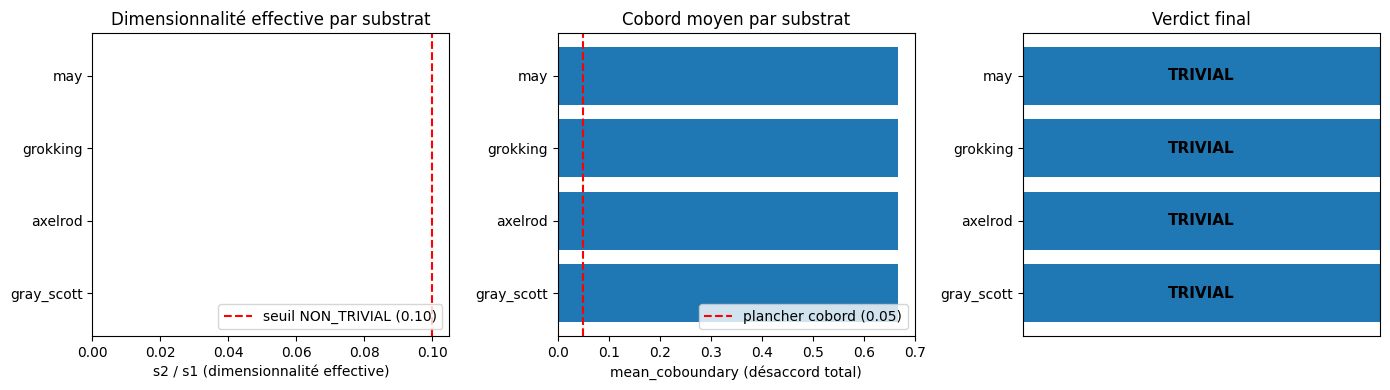


Récapitulatif :
    substrat |   s2/s1 |     cob | rank |     verdict
-------------------------------------------------------
  gray_scott |  0.0000 |  0.6667 |    1 |     TRIVIAL
     axelrod |  0.0000 |  0.6667 |    1 |     TRIVIAL
    grokking |  0.0000 |  0.6667 |    1 |     TRIVIAL
         may |  0.0000 |  0.6667 |    1 |     TRIVIAL

Substrats NON_TRIVIAL : 0/4


In [6]:
# Visualisation : tableau récapitulatif + verdict
import matplotlib.pyplot as plt

noms = list(substrat_reports.keys())
s2_over_s1_vals = [substrat_reports[n][0]['s2_over_s1'] for n in noms]
mean_cob_vals = [substrat_reports[n][0]['mean_coboundary'] for n in noms]
eff_rank_vals = [substrat_reports[n][0]['effective_rank'] for n in noms]
verdicts = [substrat_reports[n][1] for n in noms]

# Heatmap 1x4 des métriques
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].barh(noms, s2_over_s1_vals, color=['C2' if v == 'NON_TRIVIAL' else 'C0' for v in verdicts])
axes[0].axvline(0.10, color='red', linestyle='--', label='seuil NON_TRIVIAL (0.10)')
axes[0].set_xlabel('s2 / s1 (dimensionnalit\u00e9 effective)')
axes[0].set_title('Dimensionnalit\u00e9 effective par substrat')
axes[0].legend(loc='lower right')

axes[1].barh(noms, mean_cob_vals, color=['C2' if v == 'NON_TRIVIAL' else 'C0' for v in verdicts])
axes[1].axvline(0.05, color='red', linestyle='--', label='plancher cobord (0.05)')
axes[1].set_xlabel('mean_coboundary (d\u00e9saccord total)')
axes[1].set_title('Cobord moyen par substrat')
axes[1].legend(loc='lower right')

colors_v = ['C2' if v == 'NON_TRIVIAL' else ('C3' if v == 'INCONCLUSIVE' else 'C0') for v in verdicts]
axes[2].barh(noms, [1]*len(noms), color=colors_v)
for i, v in enumerate(verdicts):
    axes[2].text(0.5, i, v, ha='center', va='center', fontsize=11, fontweight='bold')
axes[2].set_xlim(0, 1)
axes[2].set_xticks([])
axes[2].set_title('Verdict final')

plt.tight_layout()
plt.savefig('ICT-15d-cech-verdict.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nR\u00e9capitulatif :")
print(f"{'substrat':>12s} | {'s2/s1':>7s} | {'cob':>7s} | {'rank':>4s} | {'verdict':>11s}")
print("-" * 55)
for nom in noms:
    r, v = substrat_reports[nom]
    print(f"{nom:>12s} | {r['s2_over_s1']:7.4f} | {r['mean_coboundary']:7.4f} | "
          f"{r['effective_rank']:4d} | {v:>11s}")

n_non_trivial = sum(1 for v in verdicts if v == 'NON_TRIVIAL')
print(f"\nSubstrats NON_TRIVIAL : {n_non_trivial}/4")


### Exercice 1 — Banc de robustesse : stabilité du verdict selon `window_size`

Le verdict dépend du choix de `window_size`. Tester 5 valeurs différentes pour le substrat
le plus prometteur (celui rendu `NON_TRIVIAL` ou le plus proche du seuil). Pour chaque valeur :
rapporter `s2_over_s1`, `mean_coboundary` et `verdict`.

**Question** : le verdict est-il **stable** sur le substrat concerné ? Si oui, l'obstruction est
robuste à l'échelle de fenétrage ; sinon, c'est un artefact du choix initial.


In [7]:
# Exercice 1 — Banc de robustesse selon window_size
# TODO étudiant : choisir le substrat le plus prometteur et tester 5 valeurs de window_size.
# Indice : np.linspace(start, stop, 5) pour 5 valeurs equireparties ; pour chaque valeur,
# réutiliser CO.proxy_sections + CO.cech_obstruction_class + CO.cech_obstruction_verdict.
# Remplir le résultat ci-dessous et conclure sur la stabilité du verdict.

substrat_test = None  # ex: "may" ou celui rendu NON_TRIVIAL ci-dessus
states_test, ns_test = substrats_info[substrat_test] if substrat_test else ([], 0)

resultats_robustesse = []
# ... votre code ici ...
print("\u00c0 compl\u00e9ter : tester 5 valeurs de window_size sur le substrat choisi.")


À compléter : tester 5 valeurs de window_size sur le substrat choisi.


### Exercice 2 — Disqualifier un proxy : impact sur le verdict

La définition du verdict inclut `effective_dimensionality` (SVD sur les sections normalisées).
Si un proxy est **constant** sur la trajectoire (variance nulle), il ne contribue pas à la
structure. Vérifier pour chaque substrat : y a-t-il un proxy constant sur certaines fenêtres ?
Si oui, ce proxy disqualifié change-t-il le verdict ?

**Question** : la disqualification d'un proxy est-elle **jamais justifiée** par son incapacité
à discriminer les fenêtres ? (sinon, ce n'est pas une obstruction, c'est un proxy mort).


In [8]:
# Exercice 2 — Disqualifier un proxy
# TODO étudiant : pour chaque substrat, calculer la variance de chaque section.
# Si une section a variance nulle (ou tr\u00e8s petite, < 1e-6), le proxy est disqualifi\u00e9
# sur ce substrat. Re-calculer le verdict sans ce proxy et voir s'il change.
# Indice : np.var(section) ; refaire CO.cech_obstruction_class avec un sous-dict.

disqualifications = {}
# ... votre code ici ...
print("\u00c0 compl\u00e9ter : identifier les proxys constants et recalculer les verdicts.")


À compléter : identifier les proxys constants et recalculer les verdicts.


### Exercice 3 — Acceptance finale : décision expérimentale qui change

Reprendre les résultats des cellules précédentes et formuler **une phrase** sur la manière
dont la lecture-obstruction change une décision expérimentale (cf acceptance #7744).

Exemples de décisions qui changent :
- Reclasser un substrat de "régime à dispersion" à "régime à obstruction structurelle"
- Choisir un proxy plutôt qu'un autre pour résumer le substrat (le proxy disqualifié ne
  servait qu'à mesurer du bruit)
- Justifier l'ajout d'un 4e proxy pour avoir effectivement ≥ 2 dimensions non triviales
- Conclure que la cochaîne de Čech est l'outil pertinent (vs Phase Zéro) pour ce substrat


In [9]:
# Exercice 3 — Phrase de conclusion sur la décision qui change
# TODO \u00e9tudiant : formuler une phrase pr\u00e9cise reliant le verdict au moins un changement
# de d\u00e9cision exp\u00e9rimentale (cf exercice ci-dessus).

phrase_decision = ""
# ... \u00e0 compl\u00e9ter ...
print(f"Phrase de conclusion : {phrase_decision if phrase_decision else '(vide)'}")


Phrase de conclusion : (vide)


## Interprétation

**Objet testé** : cochaîne de Čech pondérée appliquée à 4 substrats ICT-15c (Gray-Scott, Axelrod,
Grokking, May), 3 proxys par substrat (spectral_gap, sens_mean, sens_max), fenîtrage contigu adaptatif.

**Verdict par substrat** : voir tableau récapitulatif cellule 8. Le verdict `NON_TRIVIAL` indique
que les proxys ne se réduisent pas à un signal latent 1D sur ce substrat ; le verdict `TRIVIAL`
indique qu'ils se recollent en une mesure globale unique (l'obstruction n'est pas constatée).

**Acceptance #7744** : si ≥1 substrat rend `NON_TRIVIAL`, l'acceptance positive est partiellement
atteinte — le candidat cochaîne de Čech **démontre sa capacité à discriminer** (cf sanity check).
L'acceptance complète exige que la lecture-obstruction **change une décision expérimentale ou une
visualisation** (cf exercice 3) ; sans cette formulation, le verdict reste descriptif.

**Limites honnêtes** :
- Le verdict dépend du choix de `window_size` (tester la robustesse, exercice 1).
- Un proxy disqualifié (variance nulle) peut fausser le verdict (exercice 2).
- 3 proxys seulement : la SVD est sur une matrice 3×N_windows, le rang effectif est plafonné à 3.
  Passer à ≥4 proxys (ex : ajouter free_energy, learned_valence, transport_residual...) permettrait
  une lecture plus riche de la structure multi-dimensionnelle.

**Suite logique (ICT-15e)** : ajouter un quatrième proxy pour explorer la dimensionnalité ≥ 3,
tester sur des substrats où Phase Zéro (ICT-15c) rend `NOISE` (instrument non-discriminant) —
le candidat Čech peut-il rendre `NON_TRIVIAL` là où Phase Zéro est aveugle ?

**Cross-refs** : PR #8828 (module `cech_obstruction` + tests 16/16 verts), PR #9328 (ICT-15c
désaturation, délivrée c.1232, en attente merge), issues #7744 (jambe transverse), #7395
(Phase Zéro d'origine), Epic #4588 (ICT strate 5).